# R/S benchmark — 4. NN training (global R, S, t $\to$ lambda)

Trains one `MLPRegressor` for `lambda 1` and one for `lambda 2` on the dataset stacked by
[`03_generate_dataset_nn.ipynb`](03_generate_dataset_nn.ipynb). Unlike the PCE stage
(`02_train_pce.ipynb`, one model per time step), this fits a single global model that also takes
$t$ as an input — query it with any $(R, S, t)$ triple, no need to pick a PCE for a specific time
step first.

`lambda 3` / `lambda 4` are **not** modelled here — read them back from the emulator dataset
directly, as scoped when this pipeline was set up.

Functions come from [`functions.py`](../functions.py): `train_and_validate_nn_lambda_benchmark`.

## 1. Libraries

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
from sklearn.model_selection import train_test_split

from functions import *

/home/casa-wand/Documentos/2024-1_victor_hugo_renata_maria/.venv/lib/python3.11/site-packages/UQpy/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. Config

`n_latent_samples` must match [`03_generate_dataset_nn.ipynb`](03_generate_dataset_nn.ipynb) — it
names the file being loaded.

In [2]:
n_latent_samples = 2500   # must match stage 3 — it is the filename prefix

feature_cols = ['r', 's', 'Time (years)']
target_cols  = ['lambda 1', 'lambda 2']

test_frac          = 0.2
hidden_layer_sizes = (64, 64)
max_iter           = 500
n_iter_no_change   = 15
random_state       = 42

fig_size   = (5, 4)      # size of each individual figure, in inches
fig_format = 'png'       # format each figure is saved in ('pdf', 'png', ...)
fig_dpi    = 300         # resolution the figure is saved at (dots per inch)

label_fontsize = 14   # font size of the axis labels
tick_fontsize  = 12   # font size of the tick numbers

xlim = None   # e.g. (-5, 5) to fix the axis; None = auto-scaled to the data, per lambda
ylim = None   # e.g. (-5, 5) to fix the axis; None = auto-scaled to the data, per lambda

## 3. Load the stacked dataset

In [3]:
with open(f'{n_latent_samples}_dataset_nn_benchmark.pkl', 'rb') as f:
    df_nn = dill.load(f)

print(f"Loaded {len(df_nn)} rows")
df_nn.head()

Loaded 50000 rows


,r,s,Time (years),lambda 1,lambda 2,lambda 3,lambda 4
0,4.864753,2.518452,0.0,2.349110,5.249569,0.142295,0.132717
1,2.881555,1.912999,0.0,0.970985,7.498640,0.132808,0.132360
2,5.121927,1.968550,0.0,3.154849,6.114267,0.146674,0.129361
3,4.936273,1.290296,0.0,3.646073,8.077199,0.146397,0.115877
4,5.747536,2.067322,0.0,3.681521,5.652707,0.148160,0.129248


## 4. Train and validate

In [4]:
print("="*60)
print("TRAINING THE BENCHMARK NN")
print("="*60)

result = train_and_validate_nn_lambda_benchmark(
                                                   df_nn=df_nn,
                                                   feature_cols=feature_cols,
                                                   target_cols=target_cols,
                                                   test_frac=test_frac,
                                                   hidden_layer_sizes=hidden_layer_sizes,
                                                   max_iter=max_iter,
                                                   n_iter_no_change=n_iter_no_change,
                                                   random_state=random_state,
                                                   n_latent_samples=n_latent_samples,
                                                   output_dir='.',
                                                )

result['statistics']

TRAINING THE BENCHMARK NN

----------------------------------------
TRAINING NN LAMBDA MODELS
----------------------------------------
  40000 train rows, 10000 val rows


  lambda 1: R² = 0.999968, MSE = 0.00011, iterations = 19


  lambda 2: R² = 0.997612, MSE = 0.02693, iterations = 170
The NN models, scaler and validation stats have been saved!


,MSE lambda 1,R² lambda 1,MSE lambda 2,R² lambda 2
0,0.000109,0.999968,0.026933,0.997612


## 5. Predicted vs. true, on the held-out validation split

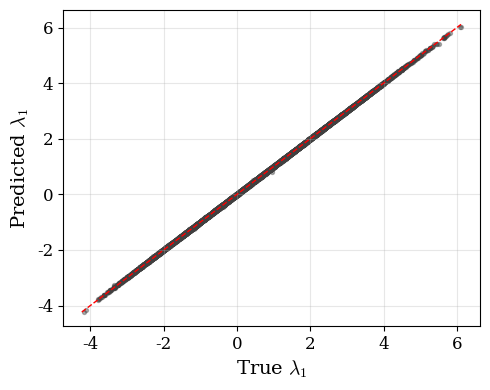

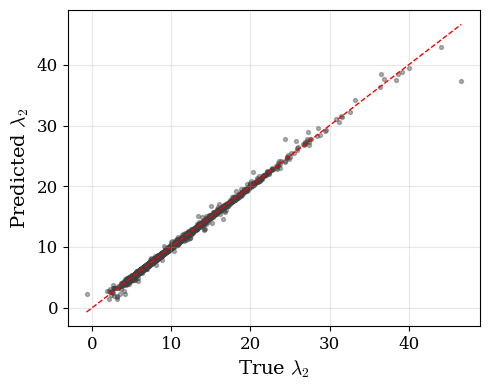

In [5]:
df_clean = df_nn.dropna(subset=target_cols).reset_index(drop=True)
X = df_clean[feature_cols].to_numpy()
y = df_clean[target_cols].to_numpy()
_, x_val, _, y_val = train_test_split(X, y, test_size=test_frac, random_state=random_state)
x_val_s = result['scaler'].transform(x_val)

pkl_name = f'{n_latent_samples}_dataset_nn_benchmark'
figs     = {}

for target in target_cols:
    y_true = y_val[:, target_cols.index(target)]
    y_pred = result['models'][target].predict(x_val_s)
    idx    = target.split(' ')[1]

    fig, ax = plt.subplots(figsize=fig_size)
    ax.scatter(y_true, y_pred, s=8, alpha=0.4, color='0.25')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel(f'True $\\lambda_{{{idx}}}$', fontsize=label_fontsize)
    ax.set_ylabel(f'Predicted $\\lambda_{{{idx}}}$', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig.savefig(f'{pkl_name}_pred_vs_true_lambda_{idx}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    figs[target] = fig
    plt.show()

## 6. Spot check — sweep $t$ at a fixed $(R, S)$

Same demo as the exploratory `old/pce_models.ipynb`: fix a design point and sweep $t$, to see the
predicted lambdas evolve smoothly with time.

In [6]:
r_fixed     = 5.0
s_fixed     = 2.0
times_sweep = np.linspace(0, 150, 10, endpoint=True)

sweep_df = pd.DataFrame({
                           'r':            [r_fixed] * len(times_sweep),
                           's':            [s_fixed] * len(times_sweep),
                           'Time (years)': times_sweep,
                        })

x_sweep_s = result['scaler'].transform(sweep_df[feature_cols].to_numpy())
for target in target_cols:
    sweep_df[f'pred_{target}'] = result['models'][target].predict(x_sweep_s)

sweep_df

,r,s,Time (years),pred_lambda 1,pred_lambda 2
0,5.0,2.0,0.000000,3.003417,6.135591
1,5.0,2.0,16.666667,2.428185,6.358944
2,5.0,2.0,33.333333,1.830785,6.780019
3,5.0,2.0,50.000000,1.262719,7.099942
4,5.0,2.0,66.666667,0.678713,7.050521
5,5.0,2.0,83.333333,0.084765,7.723547
6,5.0,2.0,100.000000,-0.493654,7.587587
7,5.0,2.0,116.666667,-1.076791,7.809118
8,5.0,2.0,133.333333,-1.674754,7.313981
9,5.0,2.0,150.000000,-2.243524,7.769539
